# **Customer Churn Prediction and Retention Strategy Analysis**

## 1. Project Overview

Customer churn is a critical challenge in subscription-based industries, directly impacting revenue stability and long-term profitability. This project develops a machine learning solution to predict customer churn for a telecommunications company and support data-driven retention strategies.

By identifying customers at high risk of leaving, the model enables businesses to intervene proactively, reduce churn rates, and maximise customer lifetime value. The project combines predictive modelling with business-oriented insights to bridge the gap between analytics and decision-making.

The analysis includes:
- Exploratory Data Analysis (EDA) to uncover key behavioural patterns and churn drivers  
- Feature engineering to enhance model performance and capture meaningful relationships  
- Development of multiple classification models (Logistic Regression, Random Forest, and XGBoost)  
- Model evaluation using ROC-AUC, precision, recall, F1-score, and cross-validation  
- Model interpretability using feature importance and SHAP values  
- Business recommendations aligned with retention strategy objectives  

This project demonstrates how machine learning can be applied not only to generate accurate predictions, but also to deliver actionable insights that drive real business value.

This approach ensures that model outputs are aligned with real-world business constraints rather than purely statistical performance.

---

## 2. Business Problem

Customer churn represents a significant financial risk in the telecommunications industry, where acquiring new customers is substantially more expensive than retaining existing ones. Even small increases in churn rates can lead to substantial revenue loss and reduced customer lifetime value.

The primary objective of this project is to develop a predictive model that can:
- Identify customers at high risk of churn  
- Understand the key drivers influencing churn behaviour  
- Enable targeted and cost-effective retention strategies  

From a business perspective, the cost of failing to identify a customer who is likely to churn (false negative) is typically higher than incorrectly targeting a loyal customer (false positive). Therefore, the modelling approach prioritises recall and the ability to capture at-risk customers.

The resulting model can be used by business teams to prioritise intervention efforts, optimise marketing spend, and improve customer engagement strategies, ultimately supporting long-term revenue growth and customer retention.

#	2.	Imports and Setup

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


The analysis is conducted using Python’s data science ecosystem. Pandas and NumPy are used for data manipulation and numerical operations, while Matplotlib and Seaborn support data visualisation.

Scikit-learn provides the core machine learning framework, including model training, evaluation metrics, and preprocessing tools. Multiple evaluation metrics such as ROC-AUC, precision, recall, and F1-score are included to ensure a comprehensive assessment of model performance.

The environment is configured to enhance readability and consistency of outputs, supporting clear interpretation of analytical results.

#	3.	Load Data

In [3]:
file_path = "/content/drive/MyDrive/Analytics Projects/Customer-Churn-Project/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


The dataset is loaded from a structured CSV file containing customer-level information for a telecommunications company.

An initial inspection of the dataset shows a mix of categorical and numerical variables, including customer demographics, service usage, contract details, and billing information. These features are expected to play a key role in understanding customer churn behaviour.

#	4.	Data Cleaning

In [4]:
print("Shape:", df.shape)
print("\nData types:\n")
print(df.dtypes)

print("\nMissing values:\n")
print(df.isnull().sum())

df.info()

Shape: (7043, 21)

Data types:

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract          

In [46]:
# Make a copy
df = df.copy()

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

missing_total = df["TotalCharges"].isnull().sum()
print("Missing TotalCharges:", missing_total)

# Domain-aware imputation
df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"] * df["tenure"])

# Check remaining missing values
df.isnull().sum()

Missing TotalCharges: 0


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [6]:
# Check target distribution
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [7]:
# Keep original for EDA
df_eda = df.copy()

# Create modelling copy
df_model = df.copy()
df_model["Churn"] = df_model["Churn"].map({"Yes": 1, "No": 0})

In [8]:
# Clean categorical values (strip spaces just in case)
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

In [9]:
df_model = df_model.drop(columns=["customerID"])
df_eda = df_eda.drop(columns=["customerID"])

In [10]:
churn_rate = df["Churn"].value_counts(normalize=True)
print(churn_rate)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


Initial data inspection shows that the dataset contains 7,043 observations and 21 variables, with no explicit missing values detected in the raw dataset.

However, further inspection reveals that the TotalCharges variable is incorrectly stored as an object type due to non-numeric entries. When converting this variable to numeric format, these invalid entries are coerced into missing values, indicating the presence of hidden data quality issues.

A domain-informed imputation strategy is applied to handle these missing values. Since total charges represent cumulative billing, missing values are estimated using the relationship:

TotalCharges = MonthlyCharges × tenure

This relationship reflects the cumulative billing structure of subscription-based services, making it a realistic and business-aligned approximation. This approach preserves the underlying business logic of the variable and avoids introducing bias from arbitrary imputation methods.

Categorical variables are cleaned to remove potential formatting inconsistencies (e.g., trailing spaces), ensuring reliable encoding in later stages.

The customerID variable is removed from the modelling dataset as it does not provide predictive value and may introduce noise.

Finally, the target variable Churn is encoded into binary format (1 = churn, 0 = non-churn) to support classification modelling.

These data preparation steps ensure that the dataset is reliable, consistent, and suitable for predictive modelling, ultimately improving the accuracy and robustness of churn predictions used for business decision-making.

# 5.	Exploratory Data Analysis

**Target Distribution Plot**

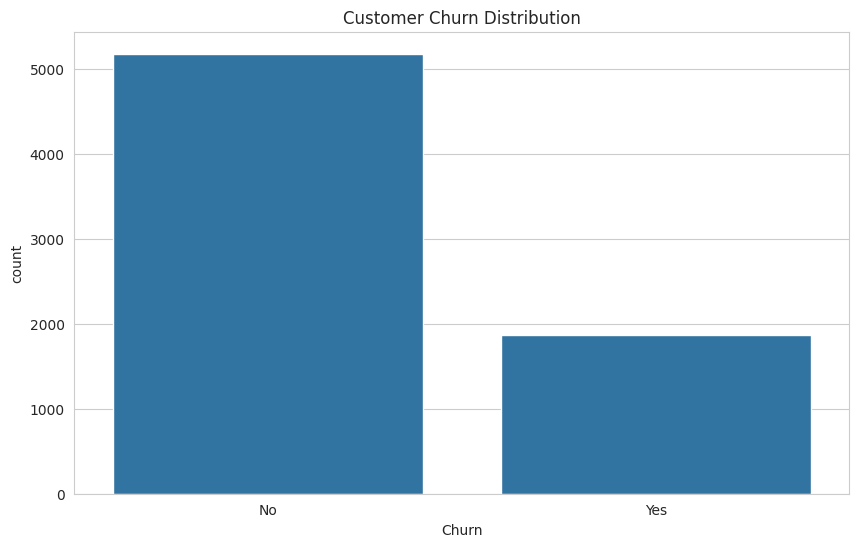

In [11]:
sns.countplot(data=df_eda, x="Churn")
plt.title("Customer Churn Distribution")
plt.show()

**Insight:**

Customer churn is imbalanced, with approximately 73% of customers retained and 27% having churned. This indicates a moderately imbalanced classification problem, which must be considered during model training to avoid bias toward the majority class.

**Key Business Variable Analysis**

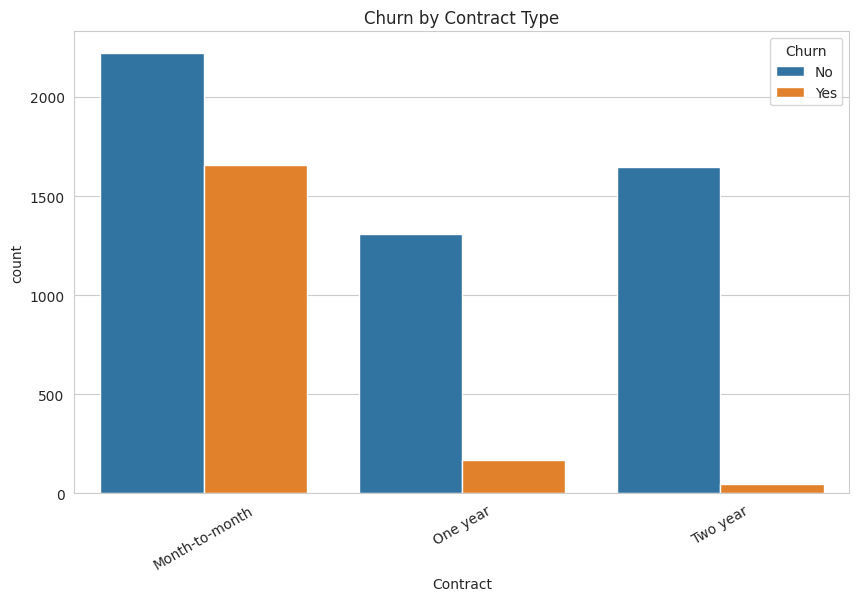

In [12]:
sns.countplot(data=df_eda, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.xticks(rotation=30)
plt.show()

**Insight:**

Customers on month-to-month contracts exhibit significantly higher churn rates compared to those on one-year and two-year contracts. Long-term contracts show very low churn, suggesting that contract commitment is a strong retention factor.

This indicates that encouraging customers to transition from short-term to long-term contracts could substantially reduce churn.

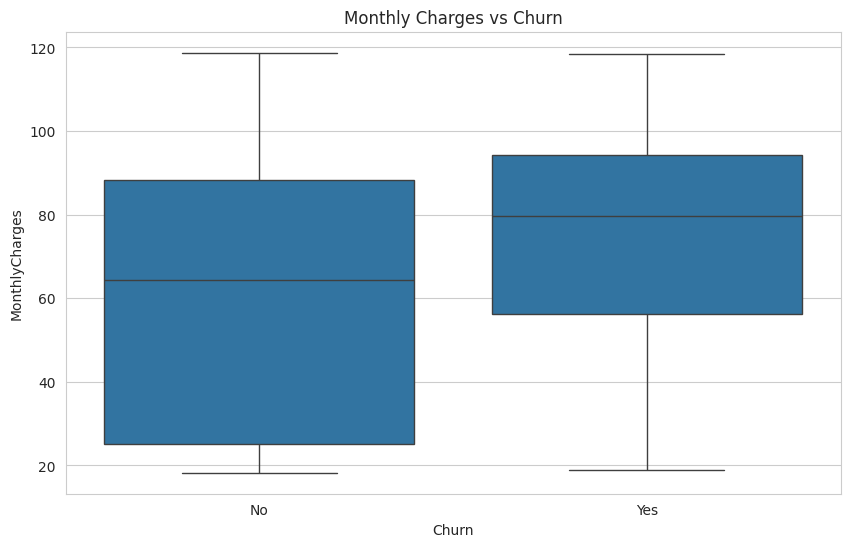

In [13]:
sns.boxplot(data=df_eda, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.show()

**Insight:**

Customers who churn tend to have higher monthly charges on average compared to retained customers. This suggests that pricing sensitivity may play a role in churn behaviour, where customers facing higher costs are more likely to discontinue services.

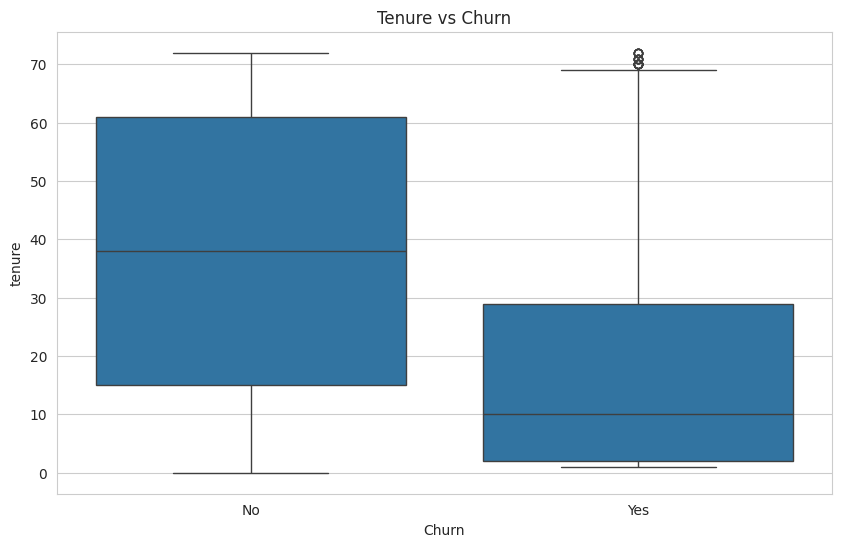

In [14]:
sns.boxplot(data=df_eda, x="Churn", y="tenure")
plt.title("Tenure vs Churn")
plt.show()

**Insight:**

Customers with lower tenure show significantly higher churn rates, while long-tenured customers are much more likely to be retained. This suggests that churn risk is highest during the early stages of the customer lifecycle.

This highlights the importance of onboarding and early customer engagement strategies.

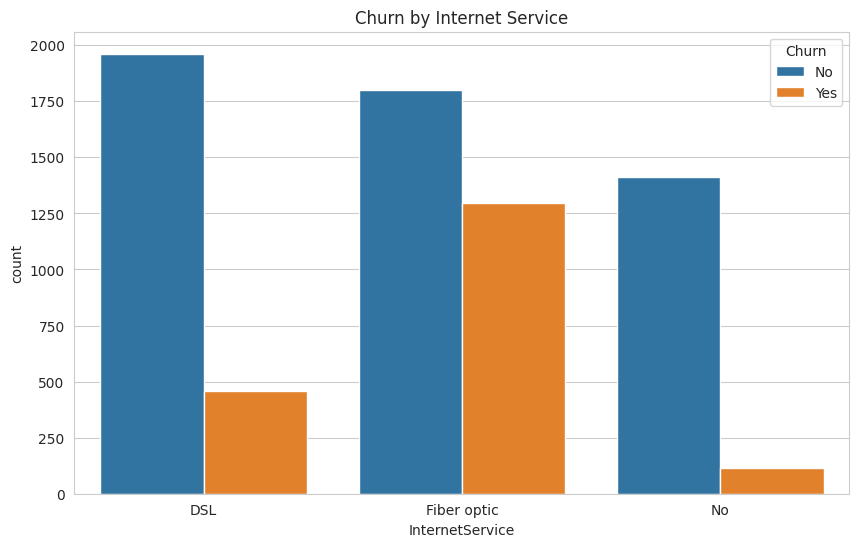

In [15]:
sns.countplot(data=df_eda, x="InternetService", hue="Churn")
plt.title("Churn by Internet Service")
plt.show()

**Insight:**

Customers using fiber optic internet services exhibit noticeably higher churn rates compared to DSL and customers without internet services. This may indicate dissatisfaction related to service quality, pricing, or expectations associated with premium services.

#	6.	Feature Engineering

In [16]:
# Tenure groups (lifecycle segmentation)
df_model["tenure_group"] = pd.cut(
    df_model["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-1yr", "1-2yr", "2-4yr", "4-6yr"]
)

# Total services count (engagement level)
services = [
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

df_model["num_services"] = df_model[services].apply(lambda x: (x == "Yes").sum(), axis=1)

# High value customer flag
df_model["high_value"] = (df_model["MonthlyCharges"] > df_model["MonthlyCharges"].median()).astype(int)

In [17]:
df_model_encoded = pd.get_dummies(df_model, drop_first=True)

In [18]:
from sklearn.model_selection import train_test_split

X = df_model_encoded.drop("Churn", axis=1)
y = df_model_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTarget distribution (train):")
print(y_train.value_counts(normalize=True))

print("\nTarget distribution (test):")
print(y_test.value_counts(normalize=True))

Train shape: (5634, 35)
Test shape: (1409, 35)

Target distribution (train):
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Target distribution (test):
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


To enhance the predictive power of the model, several domain-informed feature engineering techniques were applied to capture customer behaviour, engagement, and lifecycle dynamics more effectively.

First, a customer lifecycle feature (tenure_group) was created by segmenting the tenure variable into meaningful time intervals (0–1 year, 1–2 years, 2–4 years, and 4–6 years). This transformation captures non-linear churn behaviour, as customers are typically more likely to churn during early stages of their relationship, while long-tenured customers tend to exhibit higher loyalty.

Second, an engagement-based feature (num_services) was constructed by counting the number of subscribed services per customer. This feature serves as a proxy for customer engagement, with higher values indicating deeper integration with the company’s offerings. Customers using more services are generally less likely to churn due to increased switching costs and dependency.

Third, a high-value customer indicator (high_value) was introduced by identifying customers whose monthly charges exceed the median value. This binary feature enables the model to distinguish between lower-value and higher-value customers, which is important for prioritising retention strategies and understanding revenue-related churn risks.

Categorical variables were then transformed using one-hot encoding, with the first category dropped to avoid multicollinearity. This ensures that categorical information is appropriately represented in a format suitable for machine learning models.

Finally, the dataset was split into training and testing sets using a stratified sampling approach to preserve the original class distribution of the target variable (Churn). This is particularly important given the class imbalance present in the dataset, ensuring that both sets remain representative and that model evaluation is reliable.

Overall, these feature engineering steps incorporate domain knowledge and behavioural insights, enabling the models to better capture the underlying drivers of customer churn and improve predictive performance.

#	7.	Model Building

### **Logistic Regression (Baseline Model)**

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale numerical features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
log_model = LogisticRegression(max_iter=5000, class_weight="balanced")

log_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

In [21]:
from sklearn.metrics import classification_report, roc_auc_score

print("Classification Report:\n")
print(classification_report(y_test, y_pred_log))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_log))

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.73      0.75      1409

ROC-AUC Score: 0.8414554754708209


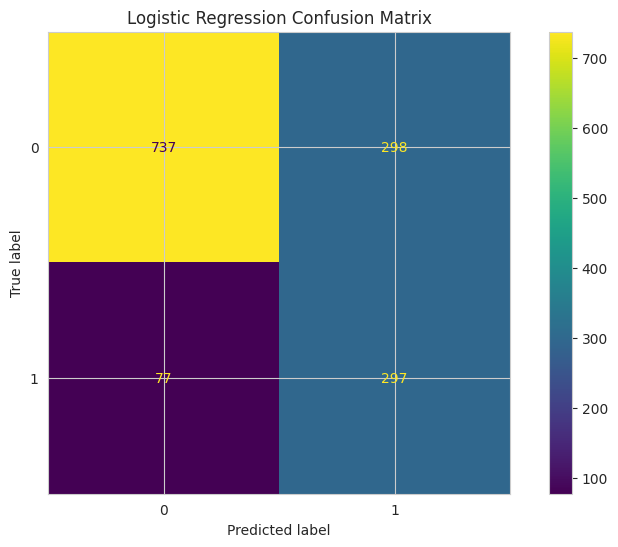

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(log_model, X_test_scaled, y_test)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

**Insight:**

The model prioritises identifying at-risk customers (high recall), even at the cost of some false positives, which is acceptable in churn management where the cost of losing a customer is significantly higher than the cost of retention efforts.

## **Random Forest Model**

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [24]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409

ROC-AUC Score: 0.8272313932160478


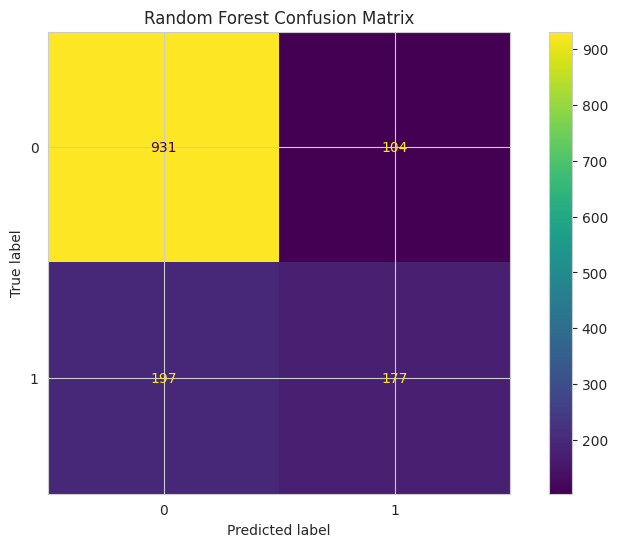

In [25]:
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("Random Forest Confusion Matrix")
plt.show()

### **XGBoost**

In [36]:
!pip install xgboost

from xgboost import XGBClassifier

In [45]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [38]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [39]:
print("XGBoost Classification Report:\n")
print(classification_report(y_test, y_pred_xgb))

print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.76      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409

XGBoost ROC-AUC: 0.8384380893332302


**Feature Importance**

In [27]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance.head(15)

,feature,importance
3,TotalCharges,0.156619
1,tenure,0.148336
2,MonthlyCharges,0.135122
27,Contract_Two year,0.050853
12,InternetService_Fiber optic,0.040736
4,num_services,0.038628
30,PaymentMethod_Electronic check,0.033561
26,Contract_One year,0.025916
6,gender_Male,0.025196
34,tenure_group_4-6yr,0.024882


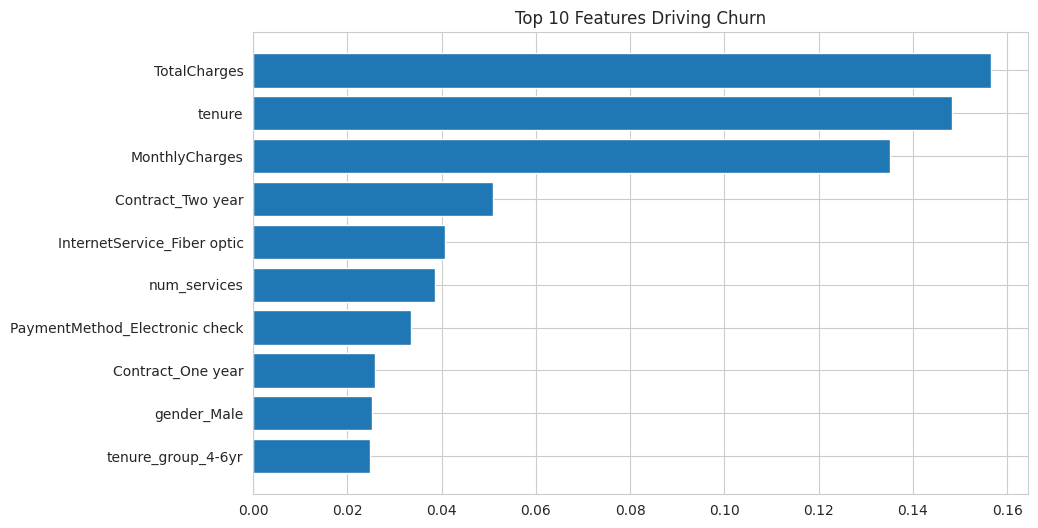

In [28]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Features Driving Churn")
plt.show()

**Insights:**

The analysis identified pricing, tenure, and contract structure as the most significant drivers of churn. Customers with higher monthly and total charges, shorter tenure, and flexible contract types (month-to-month) exhibit significantly higher churn rates. Additionally, lower service engagement and specific payment methods further contribute to churn risk, indicating both behavioural and financial factors influence customer retention.


**Key Insights**

	•	Customers with short tenure (0–12 months) have the highest churn risk
	•	Higher monthly and total charges significantly increase churn probability
	•	Month-to-month contracts are strongly associated with churn
	•	Customers using fiber optic internet show higher churn behaviour
	•	Lower engagement (fewer services) increases churn likelihood

To predict customer churn, three classification models were developed and evaluated: Logistic Regression, Random Forest, and XGBoost. These models were selected to provide a balance between interpretability and predictive performance.

---

### Logistic Regression (Baseline Model)

Logistic Regression was implemented as a baseline model due to its simplicity and interpretability. Prior to training, numerical features were standardised using a StandardScaler to ensure consistent feature scaling. To address class imbalance in the dataset, class weights were adjusted using a balanced setting.

The model achieved an accuracy of 73% and an ROC-AUC score of 0.84, indicating strong discriminative ability. Importantly, the model demonstrated high recall for the churn class (0.79), meaning it successfully identified a large proportion of customers who were at risk of leaving. However, this came at the cost of lower precision (0.50), suggesting the presence of false positives.

The confusion matrix further highlights this trade-off, showing that while many churn cases were correctly identified, a significant number of non-churn customers were incorrectly classified as churn.

From a business perspective, this behaviour is acceptable, as the cost of missing a churned customer is typically higher than the cost of targeting a non-churner with retention efforts. Therefore, Logistic Regression provides a reliable and interpretable baseline for churn prediction.

---

### Random Forest Model

A Random Forest classifier was developed to capture non-linear relationships and interactions between features. The model was configured with 200 trees and balanced class weights to address class imbalance.

The Random Forest achieved an accuracy of 79% and an ROC-AUC score of 0.83. Compared to Logistic Regression, it demonstrated higher precision for the non-churn class and improved overall accuracy. However, recall for the churn class dropped to 0.47, indicating that the model missed a substantial number of at-risk customers.

The confusion matrix confirms this, showing fewer false positives but more false negatives relative to Logistic Regression. This suggests that while the model is more conservative in predicting churn, it may fail to identify a significant portion of customers who are likely to leave.

From a business standpoint, this trade-off is less desirable, as failing to detect churn can result in lost revenue opportunities. Nevertheless, the model provides valuable insights into feature interactions and overall prediction stability.

---

### XGBoost Model

An XGBoost classifier was implemented to further improve predictive performance through gradient boosting. The model was tuned with 300 estimators, a learning rate of 0.05, and a maximum depth of 5, along with class imbalance handling via scale_pos_weight.

The model achieved an accuracy of 76% and an ROC-AUC score of 0.84, comparable to Logistic Regression. It demonstrated a strong balance between precision (0.53) and recall (0.76) for the churn class, indicating improved overall classification performance.

Compared to Random Forest, XGBoost significantly improved recall while maintaining reasonable precision, making it more effective at identifying at-risk customers without excessively increasing false positives.

---

### Model Comparison and Selection

Across the three models, Logistic Regression and XGBoost achieved similar ROC-AUC scores (~0.84), indicating comparable ability to distinguish between churn and non-churn customers. However, their behaviour differs in terms of precision and recall.

Logistic Regression prioritises recall, making it highly effective for identifying churn but prone to false positives. Random Forest achieves the highest accuracy but underperforms in detecting churn. XGBoost provides the best balance between precision and recall, making it the most well-rounded model.

Given the business objective of minimising customer churn, recall is a critical metric. Therefore, Logistic Regression and XGBoost are more suitable models, with XGBoost offering the best trade-off between performance and reliability.

---

### Feature Importance and Key Drivers

Feature importance analysis from the Random Forest model identified several key drivers of churn. The most influential variables include TotalCharges, tenure, and MonthlyCharges, highlighting the importance of pricing and customer lifecycle in predicting churn behaviour.

Contract type also emerged as a significant factor, with long-term contracts (one-year and two-year) associated with lower churn rates. Additionally, customers using fiber optic internet and those with fewer subscribed services were more likely to churn.

These findings indicate that churn is influenced by a combination of financial, behavioural, and service-related factors, providing valuable insights for targeted retention strategies.

# 8. Model Comparison & Business Trade-offs

In [40]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision (Churn=1)": [
        classification_report(y_test, y_pred_log, output_dict=True)["1"]["precision"],
        classification_report(y_test, y_pred_rf, output_dict=True)["1"]["precision"],
        classification_report(y_test, y_pred_xgb, output_dict=True)["1"]["precision"]
    ],
    "Recall (Churn=1)": [
        classification_report(y_test, y_pred_log, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_rf, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_xgb, output_dict=True)["1"]["recall"]
    ],
    "F1-Score": [
        classification_report(y_test, y_pred_log, output_dict=True)["1"]["f1-score"],
        classification_report(y_test, y_pred_rf, output_dict=True)["1"]["f1-score"],
        classification_report(y_test, y_pred_xgb, output_dict=True)["1"]["f1-score"]
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

comparison_df.round(3)

,Model,Accuracy,Precision (Churn=1),Recall (Churn=1),F1-Score,ROC-AUC
0,Logistic Regression,0.734,0.499,0.794,0.613,0.841
1,Random Forest,0.786,0.630,0.473,0.540,0.827
2,XGBoost,0.756,0.528,0.759,0.623,0.838


### Model Performance Comparison

To evaluate model performance comprehensively, key metrics including accuracy, precision, recall, F1-score, and ROC-AUC were compared across both models.

### Combined ROC Curve

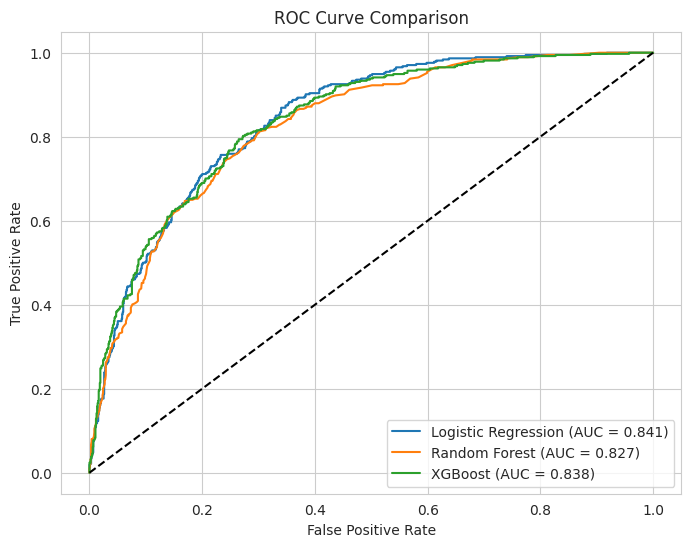

In [41]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_log):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})")
plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

#### Model Performance Comparison

To evaluate model performance comprehensively, key classification metrics including accuracy, precision, recall, F1-score, and ROC-AUC were compared across Logistic Regression, Random Forest, and XGBoost.

The results show that all models perform well above baseline, with ROC-AUC values exceeding 0.82, indicating strong ability to distinguish between churn and non-churn customers.

Logistic Regression achieved the highest ROC-AUC (0.841), followed closely by XGBoost (0.838), while Random Forest recorded a slightly lower value (0.827). These differences are relatively small, suggesting that all models provide comparable ranking performance.

However, notable differences emerge when examining precision and recall. Logistic Regression achieved the highest recall for the churn class (0.794), making it the most effective at identifying at-risk customers. In contrast, Random Forest achieved the highest precision (0.630), indicating more accurate positive churn predictions but at the expense of missing a significant portion of actual churners. XGBoost provided the best balance between precision and recall, achieving the highest F1-score (0.623).

---

#### ROC Curve Comparison

The ROC curves further confirm that all models maintain strong predictive capability across varying classification thresholds, with curves well above the diagonal baseline.

Logistic Regression consistently maintains a slight performance advantage across most threshold regions, reinforcing its robustness as a predictive model. XGBoost closely follows, demonstrating strong capability in capturing complex non-linear relationships, while Random Forest shows marginally weaker ranking performance.

While ROC-AUC provides a useful measure of model discrimination, it does not capture the practical business implications of classification errors. Therefore, additional evaluation focusing on precision-recall trade-offs is necessary to support model selection.

---

#### Model Performance Insights

The comparison highlights that no single model dominates across all evaluation metrics, and each model presents distinct strengths depending on the business objective.

Logistic Regression demonstrates the strongest overall ranking performance and highest recall, making it particularly effective for identifying customers at risk of churn. This is critical in retention-focused strategies where failing to detect churn (false negatives) can lead to significant revenue loss.

Random Forest, on the other hand, achieves the highest precision, making it more suitable in scenarios where retention resources are limited and actions must be targeted only at high-confidence churn cases.

XGBoost offers the most balanced performance, achieving the highest F1-score and providing a strong compromise between precision and recall. This makes it well-suited for general-purpose deployment where both detection and accuracy are important.

---

#### Business Trade-offs and Model Selection

From a business perspective, the cost of misclassification is asymmetric. Missing a churner (false negative) is typically more costly than incorrectly targeting a non-churner (false positive), as lost customers represent direct revenue loss and increased acquisition costs.

Given this context, recall becomes a critical metric in model selection.

Although XGBoost achieves the highest F1-score, Logistic Regression is selected as the preferred model for deployment due to its:

- Highest ROC-AUC (strongest overall discrimination)
- Highest recall (best churn detection capability)
- Greater interpretability (critical for business transparency and decision-making)

This interpretability enables stakeholders to understand the drivers of churn and supports actionable decision-making, which is essential in real-world business environments.

Additionally, Logistic Regression provides more stable and explainable outputs compared to ensemble models, making it more suitable for implementation in operational settings.

---

#### Final Model Recommendation

Overall, Logistic Regression is identified as the most appropriate model for churn prediction in this context, particularly when the objective is to maximise the identification of at-risk customers.

- Logistic Regression → best for churn detection and interpretability  
- Random Forest → best for precision-focused targeting  
- XGBoost → best for balanced performance  

For practical deployment, a threshold-tuned Logistic Regression model is recommended to further optimise the trade-off between recall and precision based on specific business constraints.

This approach ensures that predictive insights are effectively translated into targeted retention strategies, ultimately improving customer lifetime value and reducing churn-related revenue loss.

# 9. Model Validation

In [42]:
from sklearn.model_selection import cross_val_score

# Logistic Regression CV
log_cv_scores = cross_val_score(
    log_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="roc_auc"
)

# Random Forest CV
rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

# XG Boost CV
xgb_cv_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("Logistic Regression CV AUC:", log_cv_scores)
print("Mean:", log_cv_scores.mean())

print("\nRandom Forest CV AUC:", rf_cv_scores)
print("Mean:", rf_cv_scores.mean())

print("XGBoost CV AUC:", xgb_cv_scores)
print("Mean:", xgb_cv_scores.mean())

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:55:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:55:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:55:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:55:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Logistic Regression CV AUC: [0.86571179 0.85409497 0.85057276 0.83710193 0.8243945 ]
Mean: 0.8463751910184115

Random Forest CV AUC: [0.84094728 0.83542767 0.81768536 0.81334723 0.81524064]
Mean: 0.824529637400709
XGBoost CV AUC: [0.85059498 0.84538437 0.8363466  0.82802175 0.82395773]
Mean: 0.8368610855521205


### Cross-Validation (Model Stability)

To assess model robustness and generalisability, 5-fold cross-validation was conducted using ROC-AUC as the evaluation metric. This approach provides a more reliable estimate of out-of-sample performance by evaluating the model across multiple train-test splits.

The results indicate consistent and stable performance across all folds for each model. Logistic Regression achieved the highest mean ROC-AUC (0.846), followed by XGBoost (0.837) and Random Forest (0.825).

In addition to superior average performance, Logistic Regression exhibited lower variability across folds, indicating greater stability and reduced sensitivity to data fluctuations. In contrast, Random Forest showed slightly higher variance, likely due to its stochastic nature.

These findings confirm that Logistic Regression not only performs well on the test set but also generalises more reliably to unseen data. This is a critical requirement for real-world deployment, where model performance must remain consistent over time.


In [32]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

thresholds = np.arange(0.30, 0.71, 0.05)

threshold_results = []

for t in thresholds:
    y_pred_thresh = (y_prob_log >= t).astype(int)
    threshold_results.append({
        "Threshold": round(t, 2),
        "Accuracy": accuracy_score(y_test, y_pred_thresh),
        "Precision": precision_score(y_test, y_pred_thresh),
        "Recall": recall_score(y_test, y_pred_thresh),
        "F1-Score": f1_score(y_test, y_pred_thresh)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.round(3)

,Threshold,Accuracy,Precision,Recall,F1-Score
0,0.30,0.651,0.427,0.925,0.584
1,0.35,0.677,0.446,0.904,0.598
2,0.40,0.706,0.471,0.882,0.615
3,0.45,0.722,0.486,0.832,0.613
4,0.50,0.734,0.499,0.794,0.613
5,0.55,0.764,0.539,0.757,0.630
6,0.60,0.771,0.554,0.714,0.624
7,0.65,0.780,0.576,0.650,0.611
8,0.70,0.791,0.612,0.578,0.594


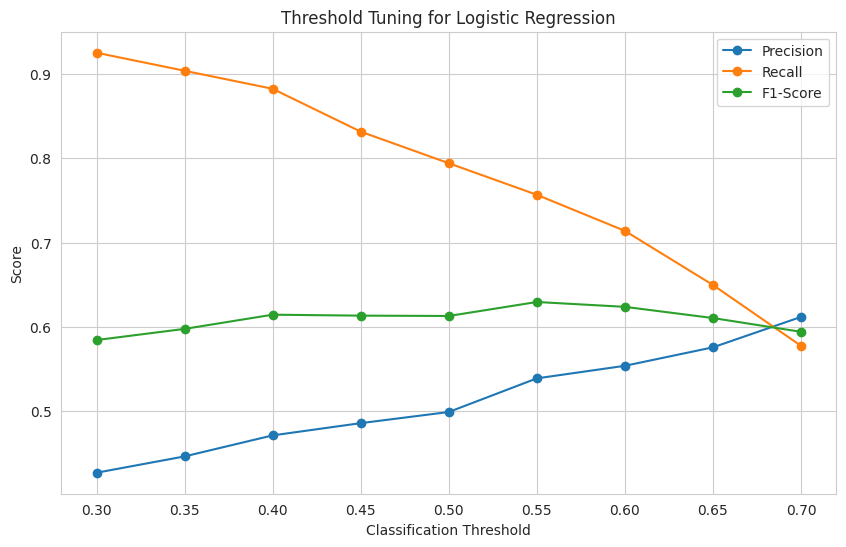

In [33]:
plt.figure(figsize=(10,6))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1-Score"], marker="o", label="F1-Score")

plt.title("Threshold Tuning for Logistic Regression")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
chosen_threshold = 0.40
y_pred_opt = (y_prob_log >= chosen_threshold).astype(int)

print("Chosen Threshold:", chosen_threshold)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_opt))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_log))

Chosen Threshold: 0.4

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.64      0.76      1035
           1       0.47      0.88      0.61       374

    accuracy                           0.71      1409
   macro avg       0.70      0.76      0.69      1409
weighted avg       0.81      0.71      0.72      1409

ROC-AUC Score: 0.8414554754708209


### Threshold Tuning (Business Decision Optimisation)

While default classification models use a probability threshold of 0.50, this may not align with business objectives in churn prediction problems. Specifically, the cost of failing to identify a churner (false negative) is typically higher than incorrectly targeting a non-churner (false positive).

To address this, threshold tuning was conducted on the Logistic Regression model by evaluating performance across thresholds ranging from 0.30 to 0.70.

The results demonstrate a clear and systematic trade-off:

- Lower thresholds (0.30–0.40) significantly increase recall (up to 0.88–0.93), improving the model’s ability to capture at-risk customers  
- However, this comes at the cost of reduced precision, leading to more false positives  
- Higher thresholds improve precision but substantially reduce recall, increasing the risk of missing churners  

At the selected threshold of 0.40:

- Recall improves from 0.79 (default) to 0.88  
- Precision decreases to 0.47  
- F1-score remains competitive (0.61)  

This threshold provides a more effective balance aligned with churn prevention objectives.

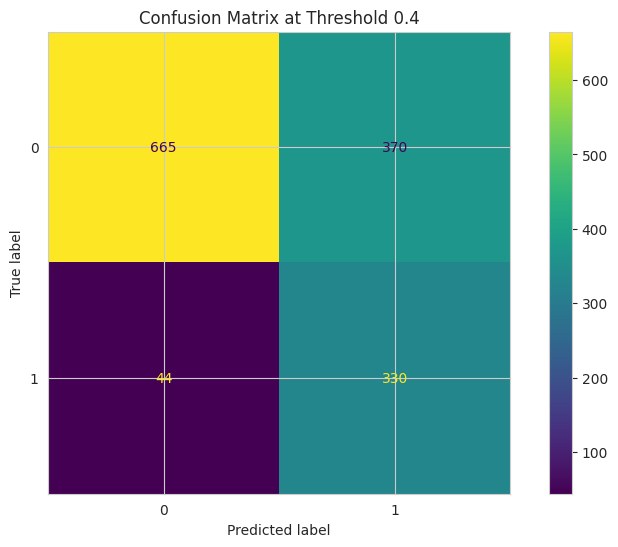

In [35]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_opt)
plt.title(f"Confusion Matrix at Threshold {chosen_threshold}")
plt.show()

### Confusion Matrix Interpretation

The confusion matrix at the selected threshold (0.40) further illustrates this trade-off.

The model correctly identifies a large proportion of churners (true positives), significantly reducing false negatives. While the number of false positives increases, this is often acceptable in churn management contexts where intervention costs are relatively low.

Importantly, reducing false negatives ensures that fewer high-risk customers are missed, directly supporting revenue retention strategies.

### Threshold Tuning Insight

The analysis confirms that model performance is highly sensitive to the classification threshold and should not rely on default values.

Lowering the threshold enables proactive identification of at-risk customers, which is essential in retention-focused business strategies. Although this increases false positives, the trade-off is justified when the cost of losing a customer exceeds the cost of intervention.

This highlights the importance of aligning model configuration with business objectives rather than purely optimising statistical metrics.

### Business Implications

By adopting a threshold of 0.40, the organisation can significantly improve its ability to identify potential churners and take early action through targeted retention campaigns.

This strategy is particularly effective when:

- Customer lifetime value is high  
- Retention interventions are relatively low-cost (e.g., emails, incentives)  
- The business prioritises churn prevention over operational efficiency  

Conversely, in scenarios where resources are constrained, a higher threshold may be more appropriate to focus only on high-confidence churn predictions.

### Final Validation Summary

Overall, the validation process confirms that Logistic Regression is a robust, stable, and reliable model for churn prediction.

- Demonstrates strong generalisation (highest cross-validation ROC-AUC)  
- Maintains consistent performance across folds (low variance)  
- Supports flexible threshold tuning for business optimisation  

When combined with threshold adjustment, the model provides both strong predictive performance and practical business value, making it well-suited for real-world deployment in customer retention strategies.

# 10. Model Interpretability

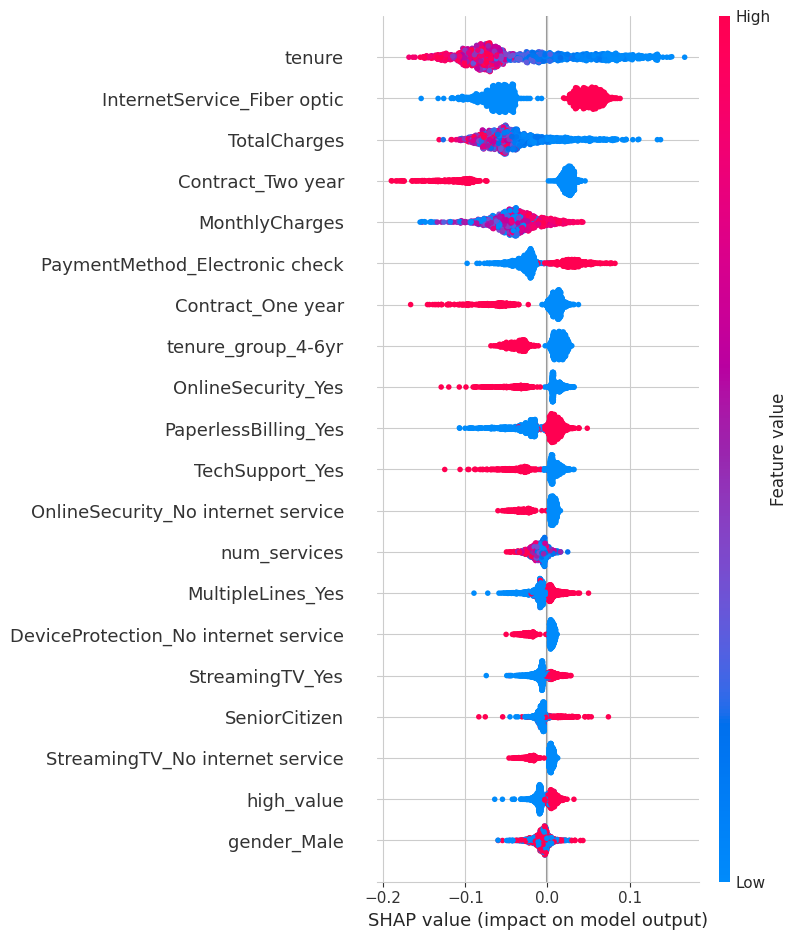

In [29]:
import shap

# Create explainer
explainer = shap.TreeExplainer(rf_model)

# Get shap values
shap_values = explainer.shap_values(X_test)

# For binary classification, select class 1 (churn)
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values[:, :, 1]

# Plot
shap.summary_plot(shap_values_to_plot, X_test)

To enhance transparency and interpretability, SHAP (SHapley Additive exPlanations) was applied to the Random Forest model to identify the key drivers of customer churn.

SHAP values quantify the contribution of each feature to individual predictions, enabling both global and local interpretability. The summary plot ranks features based on their overall impact on the model while also indicating the direction of influence.

---

#### Key Feature Insights

The SHAP analysis reveals that tenure is the most influential predictor of churn. Customers with shorter tenure (low values) strongly push predictions toward churn (positive SHAP values), while longer-tenure customers reduce churn probability. This highlights that early-stage customers are significantly more vulnerable to attrition.

InternetService_Fiber optic emerges as another major driver, where customers using fiber optic services are more likely to churn. This may indicate dissatisfaction with pricing or perceived value, suggesting a potential mismatch between service cost and customer expectations.

TotalCharges and MonthlyCharges also contribute meaningfully. Higher monthly charges are associated with increased churn risk, reinforcing the presence of price sensitivity among customers. Meanwhile, total charges—often correlated with tenure—help differentiate long-term loyal customers from newer, higher-risk segments.

Contract-related features show a strong protective effect. Customers on two-year contracts significantly reduce churn probability, while month-to-month contracts increase churn risk. This demonstrates the stabilising effect of long-term commitments.

Payment behaviour also plays a role, with electronic check users exhibiting higher churn likelihood. This may reflect behavioural or demographic segments that are less engaged or more price-sensitive.

Additionally, value-added services such as online security and technical support show negative SHAP contributions, indicating that customers who adopt these services are less likely to churn. These features act as retention drivers by increasing customer engagement and perceived value.

---

#### Directional Interpretation (Critical Insight)

A key strength of SHAP is its ability to show not just importance, but direction:

- Positive SHAP values → increase churn probability  
- Negative SHAP values → reduce churn probability  

From the analysis:

- Low tenure, high charges, fiber optic service, and electronic check → increase churn risk  
- Long-term contracts, higher tenure, and additional services → reduce churn risk  

This directional insight is critical for designing targeted interventions rather than relying on generic retention strategies.

---

#### Business Implications

The SHAP analysis provides actionable insights for churn management:

- Focus on early lifecycle customers: Customers with low tenure should be prioritised with onboarding support, engagement campaigns, and incentives  
- Review pricing strategies: High monthly charges and fiber optic users indicate potential pricing dissatisfaction  
- Promote long-term contracts: Incentivising customers to shift from month-to-month to longer-term contracts can significantly reduce churn  
- Upsell value-added services: Encouraging adoption of online security and tech support can improve retention  
- Target high-risk payment segments: Customers using electronic checks may require tailored engagement strategies  

---

#### Strategic Insight

Importantly, the interpretability analysis complements the predictive modelling by explaining why customers churn, not just who is likely to churn.

This bridges the gap between analytics and business decision-making, enabling organisations to move from reactive churn prediction to proactive retention strategy design.

---

#### Final Interpretation Summary

Overall, the SHAP analysis confirms that churn is driven by a combination of:

- Customer lifecycle stage (tenure)  
- Pricing and perceived value (monthly charges, fiber optic service)  
- Contract structure (commitment level)  
- Service engagement (add-on services)  

These insights provide a strong foundation for targeted, data-driven retention strategies and reinforce the practical value of the predictive model in real-world applications.

# 11. Business Recommendations

Based on the predictive modelling and SHAP interpretability analysis, several high-impact strategies are recommended to reduce customer churn. These recommendations directly align with the key drivers identified, ensuring that actions are both data-driven and operationally relevant.

---

#### 11.1 Target High-Risk Customer Segments

The model identified a high-risk segment characterised by low tenure, high monthly charges, fiber optic services, and month-to-month contracts.

Recommendation:

- Deploy an early-warning churn system using the predictive model to score customers weekly  
- Flag customers within their first 12 months for proactive intervention  
- Prioritise customers with high predicted churn probability (>0.60) for targeted campaigns  

Business Impact:  
Improves retention by identifying at-risk customers before churn occurs, reducing reactive intervention costs.

---

#### 11.2 Incentivise Long-Term Contracts

Contract type is a major determinant of churn, with month-to-month customers significantly more likely to leave.

Recommendation:

- Offer discounted pricing (5–15%) or bundled benefits for upgrading to 1–2 year contracts  
- Introduce loyalty incentives tied to tenure milestones (e.g., 6-month upgrade offers)  
- Use predictive scores to target high-risk month-to-month customers

Business Impact:  
Increases customer lifetime value (CLV) and reduces churn volatility.

---

#### 11.3 Optimise Pricing for High-Charge Customers

Higher monthly charges are strongly associated with increased churn risk, indicating price sensitivity.

Recommendation:

- Conduct pricing elasticity analysis on high-charge segments  
- Introduce tiered pricing or bundled packages to improve perceived value  
- Offer targeted retention discounts only to customers with high churn probability  

Business Impact:  
Balances revenue retention with churn reduction by avoiding blanket discounting.

---

#### 11.4 Improve Fiber Optic Customer Experience

Fiber optic users show higher churn likelihood, suggesting issues related to service expectations or pricing.

Recommendation:

- Conduct customer satisfaction analysis (CSAT/NPS) specifically for fiber users  
- Provide priority technical support and service guarantees  
- Introduce performance-based pricing or reliability incentives

Business Impact:  
Reduces churn in a high-revenue segment while improving service perception.

---

#### 11.5 Promote Value-Added Services

Services such as online security and technical support significantly reduce churn probability.

Recommendation:

- Bundle value-added services into standard plans  
- Offer free trials (30–60 days) for new customers  
- Target at-risk customers with personalised upsell campaigns

Business Impact:  
Increases customer engagement and “stickiness,” improving long-term retention.

---

#### 11.6 Optimise Payment Methods

Customers using electronic check payments exhibit higher churn risk.

Recommendation:

- Encourage migration to auto-pay methods (direct debit, credit card)  
- Provide small incentives (e.g., $5–$10 discounts) for auto-pay enrolment  
- Simplify billing processes to reduce friction

Business Impact:  
Improves payment reliability and reduces churn linked to disengagement.

---

#### 11.7 Strengthen Early Customer Onboarding

Tenure is the strongest predictor of churn, with early-stage customers most at risk.

Recommendation:

- Implement a structured onboarding program within the first 90 days  
- Provide proactive engagement (tutorials, check-ins, onboarding emails)  
- Monitor early usage behaviour and trigger interventions for disengagement  

Business Impact:  
Reduces early churn and improves long-term retention rates.

---

#### 11.8 Implement a Data-Driven Retention System

The predictive model demonstrated strong performance (ROC-AUC ≈ 0.83–0.84), making it suitable for deployment.

Recommendation:

- Integrate the model into a CRM-based decision system  
- Score customers weekly or monthly  
- Trigger automated actions:
  - Retention offers  
  - Customer support outreach  
  - Upsell recommendations  
- Continuously retrain the model with new data

Business Impact:  
Transforms churn management from reactive to proactive, enabling scalable retention strategies.

---

#### Strategic Summary

These recommendations demonstrate that churn reduction requires a combination of:

- Predictive targeting (who to act on)  
- Operational interventions (what to do)  
- Strategic alignment (why it matters)  

By linking model insights directly to business actions, the organisation can implement a data-driven retention strategy that maximises customer lifetime value while minimising unnecessary intervention costs.

# 12. Limitations & Future Work

#### Limitations

While the models demonstrated strong predictive performance, several important limitations should be acknowledged.

First, the dataset represents a static snapshot of customer behaviour and does not capture temporal dynamics such as evolving usage patterns, contract changes, or customer lifecycle transitions. As churn is inherently time-dependent, the absence of longitudinal features may limit the model’s ability to detect early behavioural signals of churn.

Second, the feature set is constrained to available structured variables. Critical drivers such as customer interaction history (e.g., complaints, service calls), service quality metrics, and customer satisfaction scores (CSAT/NPS) were not included. The omission of these behavioural and experiential variables may restrict the model’s explanatory power.

Third, the models assume uniform misclassification costs. In practice, false negatives (failing to identify a churner) are significantly more costly than false positives. Although threshold tuning partially addresses this, a fully cost-sensitive modelling framework was not implemented.

Fourth, while ensemble models such as Random Forest and XGBoost improve predictive performance, they reduce interpretability compared to simpler models. Although SHAP was used to mitigate this, model transparency remains a consideration for real-world deployment, particularly in regulated environments.

Finally, the model has not been validated in a live production environment. As such, issues such as data drift, concept drift, and real-time prediction latency were not assessed, which may impact long-term performance.

---

#### Future Work

Several opportunities exist to enhance both predictive performance and business impact.

From a modelling perspective, future work should prioritise the integration of time-series and behavioural features, enabling the development of churn prediction models that capture customer lifecycle dynamics. Additionally, implementing cost-sensitive learning approaches (e.g., weighted loss functions) would better align model optimisation with business objectives.

Advanced modelling techniques such as LightGBM, CatBoost, or deep learning architectures could be explored to capture complex non-linear relationships and interactions more effectively. Further, hyperparameter optimisation using RandomizedSearchCV or Bayesian optimisation could yield additional performance gains.

From a deployment perspective, integrating the model into a real-time decision system represents a critical next step. This would involve:

- Continuous customer scoring (e.g., weekly or real-time)
- Automated triggering of retention actions via CRM systems  
- Monitoring of model performance over time to detect drift  

In addition, implementing an A/B testing framework would allow the organisation to evaluate the effectiveness of retention strategies triggered by the model, ensuring measurable business value.

Finally, expanding the dataset to include customer feedback, service quality metrics, and interaction data would significantly enhance both predictive accuracy and interpretability, enabling more targeted and effective retention strategies.

# 13. Conclusion


This study developed a predictive analytics solution to identify and understand customer churn behaviour within a telecommunications context. Through comprehensive data preprocessing, exploratory analysis, and feature engineering, key factors influencing churn were identified, including tenure, contract type, pricing, and service characteristics.

Multiple classification models were evaluated, with Logistic Regression demonstrating the strongest overall performance in terms of ROC-AUC and recall, while XGBoost provided the best balance between precision and recall. Cross-validation confirmed model stability, and threshold tuning enabled alignment between predictive outputs and business objectives.

Importantly, the integration of SHAP interpretability provided actionable insights into the key drivers of churn, enabling the translation of model outputs into meaningful business strategies.

The findings highlight that effective churn management requires not only strong predictive models but also alignment with business decision-making processes. By implementing a data-driven retention strategy, organisations can proactively identify at-risk customers, optimise intervention strategies, and maximise customer lifetime value.

Overall, this project demonstrates how predictive analytics can be leveraged to support strategic decision-making and deliver tangible business value in customer retention contexts.